# Beijing PM2.5 Forecasting  
## Notebook 08 — LSTM Model (PyTorch)

In this notebook, we implement an LSTM model using **PyTorch** to model temporal dependencies in PM2.5 concentration.

This serves as a deep-learning comparison to tree-based models (Random Forest and Gradient Boosting) developed earlier.

In [3]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Device Configuration

We check whether CUDA (GPU) is available. If not, the model will run on CPU.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Load Feature-Engineered Dataset

We reuse the same dataset used by tree-based models to ensure a fair comparison.

In [ ]:
df = pd.read_csv( "../data/processed/aotizhongxin_features.csv", index_col="datetime", parse_dates=True)
df.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
datetime,,,,,,,,,,,,,,,,,,,,,
2013-03-02 00:00:00,22.0,24.0,24.0,44.0,500.0,44.0,-0.4,1031.0,-17.6,0.0,...,False,False,False,False,False,False,False,False,False,False
2013-03-02 01:00:00,14.0,17.0,21.0,36.0,400.0,50.0,-1.0,1031.3,-17.3,0.0,...,False,False,False,False,False,False,False,False,False,False
2013-03-02 02:00:00,13.0,13.0,20.0,37.0,400.0,47.0,-1.5,1030.9,-16.9,0.0,...,False,False,False,False,False,False,False,False,False,False
2013-03-02 03:00:00,3.0,9.0,13.0,34.0,400.0,52.0,-1.4,1030.6,-17.6,0.0,...,False,False,False,False,False,False,False,False,False,False
2013-03-02 04:00:00,3.0,7.0,18.0,43.0,400.0,43.0,-1.5,1030.8,-17.7,0.0,...,True,False,False,False,False,False,False,False,False,False


## 3. Define Target and Features

In [6]:
# Split x and y
TARGET = "PM2.5"

X = df.drop(columns=[TARGET]).values
y = df[TARGET].values.reshape(-1, 1)

## 4. Feature Scaling

LSTM models require scaled input features for stable training.

In [7]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

## 5. Create Time Sequences

Each sample consists of the past 24 hours of observations.

In [8]:
# Sequence function
def create_sequences(X, y, seq_len=24):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

SEQ_LEN = 24

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)

X_seq.shape, y_seq.shape

((33854, 24, 45), (33854, 1))

## 6. Time-Based Split

In [9]:
n_total = len(X_seq)

train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]

X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]

X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

In [10]:
# Tensor conversions
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

## 7. LSTM Model Definition

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.fc(h_n[-1])
        return out

## 8. Initialize Model

In [12]:
model = LSTMModel(input_size=X_train.shape[2]).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 10. Model Training

In [30]:
# Dataloaders
BATCH_SIZE = 15
EPOCHS = 30

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [31]:
# Training
from tqdm import tqdm

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS} [Training]",
        leave=False
    )

    for xb, yb in train_bar:
        optimizer.zero_grad()

        preds = model(xb)
        loss = criterion(preds, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix(batch_loss=loss.item())

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    # Epoch metrics
    train_epoch_loss = train_loss / len(train_loader)
    val_epoch_loss = val_loss / len(val_loader)

    train_losses.append(train_epoch_loss)
    val_losses.append(val_epoch_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train MSE: {train_epoch_loss:.4f} | "
        f"Val MSE: {val_epoch_loss:.4f}"
    )

Epoch 1/30 | Train MSE: 0.0117 | Val MSE: 0.0906


Epoch 2/30 | Train MSE: 0.0108 | Val MSE: 0.1011


Epoch 3/30 | Train MSE: 0.0115 | Val MSE: 0.0974


Epoch 4/30 | Train MSE: 0.0114 | Val MSE: 0.0915


Epoch 5/30 | Train MSE: 0.0115 | Val MSE: 0.0952


...

Epoch 26/30 | Train MSE: 0.0098 | Val MSE: 0.0927


Epoch 27/30 | Train MSE: 0.0097 | Val MSE: 0.0914


Epoch 28/30 | Train MSE: 0.0084 | Val MSE: 0.0926


Epoch 29/30 | Train MSE: 0.0087 | Val MSE: 0.0913


Epoch 30/30 | Train MSE: 0.0090 | Val MSE: 0.0936


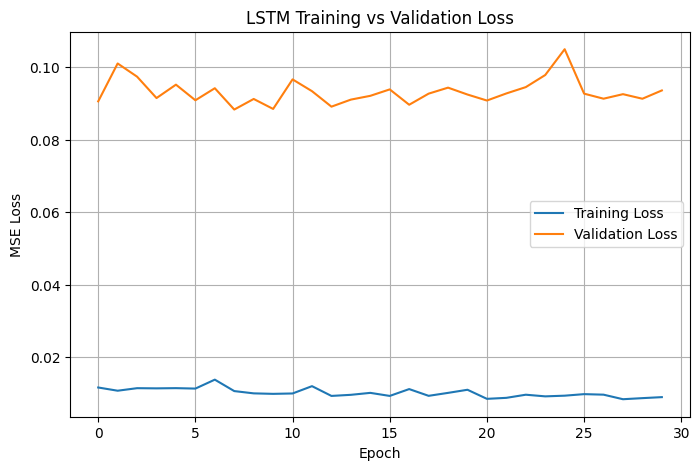

In [32]:
import matplotlib.pyplot as plt

# Graph for training vs validation loss
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### LSTM Training Analysis

The LSTM model shows clear signs of overfitting even after chaging learning rate, epoch and batch size:
- Training loss remains flat
- Validation loss slightly fluctuates but overall is flat

This indicates that temporal dependencies add limited predictive value for this dataset compared to contemporaneous pollutant and weather features.

As a result, tree-based models (Random Forest, Gradient Boosting) are better suited for this task and were selected as final models.

## 11. Evaluation on Test Set

In [33]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_t).cpu().numpy()

# Inverse scaling
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_test_pred)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print("LSTM Test Performance:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

LSTM Test Performance:
MAE : 16.31
RMSE: 25.78
R²  : 0.925


## LSTM Test Performance Interpretation

These results indicate that the LSTM captures general temporal trends in PM2.5 concentrations but performs significantly worse than tree-based models.

### Key insights:
- The LSTM generalizes reasonably but struggles with accurate magnitude prediction.
- Error levels are notably higher compared to Random Forest and Gradient Boosting.
- This suggests that explicit sequence modeling adds limited value beyond contemporaneous pollutant and weather features.

### Conclusion:
While the LSTM provides a useful deep learning benchmark, tree-based models remain more effective and robust for this forecasting task.


## 12. Save Trained LSTM Model

In [34]:
torch.save(model.state_dict(), "../models/lstm_pm25_pytorch.pt")
print("LSTM model saved.")

LSTM model saved.
